**SIGNATEのコンペ「【練習問題】銀行の顧客ターゲティング」**

ある銀行の顧客属性データおよび、過去のキャンペーンでの接触情報などから当該のキャンペーンの結果、口座を開設したかどうかを予測する。

[リンク](https://user.competition.signate.jp/ja/competition/detail/?competition=092375ab3c4a43c18c8277e1fd264aa9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# train.csv, test.csv, submit_sample.csvの中を確認する

先に簡単そうなsubmit_sample.csv(提出用csvのサンプル)から

In [ ]:
# submit_sample.csv
submit_sample = pd.read_csv("submit_sample.csv",header=None, index_col=0)
submit_sample.columns = [""]
submit_sample.index.name = None
pd.concat([submit_sample.head(), submit_sample.tail()])

,
1,0.236
2,0.128
3,0.903
4,0.782
5,0.597
18079,0.981
18080,0.461
18081,0.010
18082,0.472
18083,0.227


コンペのサイトでは各カラムの説明は以下のようににされている。

| カラム | ヘッダ名称 | データ型 | 説明                              |
|:-----------:|:------------|:---------|:---------------------------------|
| 0           | 無し        | int      | インデックスとして使用する通し番号 |
| 1           | 無し        | float    | 予測した定額預金申し込みの確率値   |

In [ ]:
submit_sample.describe().loc[["min", "max"]]

,
min,0.0
max,1.0


題意からも分かるが、maxとminを確認すると、0から1の範囲に収まる値で提出しなければならない。



次にtrain.csvとtest.csvを確認していく。

In [ ]:
# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None
pd.concat([train_data.head(), train_data.tail()])

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,39,blue-collar,married,secondary,no,1756,yes,no,cellular,3,apr,939,1,-1,0,unknown,1
2,51,entrepreneur,married,primary,no,1443,no,no,cellular,18,feb,172,10,-1,0,unknown,1
3,36,management,single,tertiary,no,436,no,no,cellular,13,apr,567,1,595,2,failure,1
4,63,retired,married,secondary,no,474,no,no,cellular,25,jan,423,1,-1,0,unknown,1
5,31,management,single,tertiary,no,354,no,no,cellular,30,apr,502,1,9,2,success,1
27124,42,blue-collar,married,primary,no,1455,yes,no,cellular,2,feb,279,2,269,2,other,0
27125,34,services,single,secondary,no,719,yes,no,unknown,15,may,362,3,-1,0,unknown,0
27126,36,blue-collar,single,primary,no,49,yes,no,unknown,8,may,405,1,-1,0,unknown,0
27127,33,housemaid,married,primary,no,209,no,no,cellular,12,aug,76,4,-1,0,unknown,0
27128,29,services,single,secondary,no,40,yes,no,cellular,18,may,105,1,355,2,failure,0


In [ ]:
# test.csv
test_data = pd.read_csv("test.csv", index_col=0)
test_data.index.name = None
pd.concat([test_data.head(), test_data.tail()])

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
1,30,management,single,tertiary,no,1028,no,no,cellular,4,feb,1294,2,-1,0,unknown
2,39,self-employed,single,tertiary,no,426,no,no,unknown,18,jun,1029,1,-1,0,unknown
3,38,technician,single,tertiary,no,-572,yes,yes,unknown,5,jun,26,24,-1,0,unknown
4,34,technician,single,secondary,no,-476,yes,no,unknown,27,may,92,4,-1,0,unknown
5,37,entrepreneur,married,primary,no,62,no,no,cellular,31,jul,404,2,-1,0,unknown
18079,30,management,married,tertiary,no,32,yes,no,unknown,6,may,122,3,-1,0,unknown
18080,35,management,married,tertiary,no,1557,yes,yes,cellular,5,feb,225,1,268,1,failure
18081,33,housemaid,married,primary,no,1713,yes,no,unknown,8,may,22,1,-1,0,unknown
18082,37,blue-collar,married,secondary,no,-251,yes,no,cellular,12,may,146,3,370,1,failure
18083,34,technician,married,secondary,no,56,no,no,cellular,19,aug,91,2,-1,0,unknown


train.csvとtest.csvを比較すると、train.csvファイルは最終列に'y'列が追加されており、0か1かで値が入っている。
これは「定額預金申し込み有無（1:有り, 0:無し）」の値であることがコンペのサイトで説明されている。
また、各カラムの説明は以下のようににされている。

| カラム | ヘッダ名称 | データ型 | 説明 |
|:-----------:|:------------|:---------|:----------------------------------------------------------|
| 0   | `id`        | int      | 行の通し番号 |
| 1   | `age`       | int      | 年齢 |
| 2   | `job`       | varchar  | 職種 |
| 3   | `marital`   | varchar  | 未婚/既婚 |
| 4   | `education` | varchar  | 教育水準 |
| 5   | `default`   | varchar  | 債務不履行があるか（yes, no） |
| 6   | `balance`   | int      | 年間平均残高（€） |
| 7   | `housing`   | varchar  | 住宅ローン（yes, no） |
| 8   | `loan`      | varchar  | 個人ローン（yes, no） |
| 9   | `contact`   | varchar  | 連絡方法 |
| 10  | `day`       | int      | 最終接触日 |
| 11  | `month`     | char     | 最終接触月 |
| 12  | `duration`  | int      | 最終接触時間（秒） |
| 13  | `compaign`  | int      | 現キャンペーンにおける接触回数 |
| 14  | `pdays`     | int      | 経過日数（前キャンペーン接触後の日数） |
| 15  | `previous`  | int      | 接触実績（現キャンペーン以前の接触回数） |
| 16  | `poutcome`  | varchar  | 前回のキャンペーンの成果 |
| 17  | `y`         | boolean  | 定額預金申し込み有無（1:有り, 0:無し） ※train.csvのみ |

今回はidをindex_colに設定し、DataFrameを見やすくするためにヘッダ名称を削除

次に、使えそうなデータや使えなさそうなデータを探していく。
詳しくデータを確認する前にヘッダ名称から予想できることを羅列する。
1.   contactは要らないだろう

特に言うことも無し
2.   jobもまあ要らないだろう

一部の職が傾向的に強く出る可能性は否定できないが、ほとんどが関係なさそうで、説明変数として採用すると要らない変化を作りそう。

3.   housingとloanは似た傾向にある変数なので一つにする

housingのみ、あるいはloanのみ、あるいはどちらかでもyesであればyesとして処理する、のどれかが良いと思われる。
相関がなさそうならそもそも説明変数として採用しない。

4.   day,monthはyearの情報がないと使えないのでは

yearがあれば最終接触からどれだけの期間が空いたかのような変数にもできたが、dayとmanthだけだとそれも叶わず、使い道が無さそう。
そもそもpdaysで同じことができるので、それで良さそう。


他はデータを確認しながら考えていく。

In [ ]:
train_data.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000,27128.000000
mean,40.951010,1355.800870,15.806215,260.711295,2.751769,40.528052,0.579733,0.117001
std,10.608542,3003.305272,8.337904,260.091727,3.126594,100.382462,2.503653,0.321427
min,18.000000,-6847.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,104.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,449.000000,16.000000,182.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,323.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


In [ ]:
train_data_varch = train_data[["job","marital","education","default","housing","loan","contact","month","poutcome","y"]]
for col in train_data_varch.columns:
    print(train_data_varch[col].value_counts())
    print()

job
blue-collar      5886
management       5620
technician       4491
admin.           3085
services         2506
retired          1391
self-employed     945
entrepreneur      914
unemployed        790
housemaid         765
student           557
unknown           178
Name: count, dtype: int64

marital
married     16411
single       7662
divorced     3055
Name: count, dtype: int64

education
secondary    13882
tertiary      7959
primary       4150
unknown       1137
Name: count, dtype: int64

default
no     26644
yes      484
Name: count, dtype: int64

housing
yes    15125
no     12003
Name: count, dtype: int64

loan
no     22788
yes     4340
Name: count, dtype: int64

contact
cellular     17580
unknown       7861
telephone     1687
Name: count, dtype: int64

month
may    8317
jul    4136
aug    3718
jun    3204
nov    2342
apr    1755
feb    1586
jan     846
oct     439
sep     356
mar     299
dec     130
Name: count, dtype: int64

poutcome
unknown    22150
failure     2969
other      

これらのデータから各要素について

1.   age

使えるかもしれないが、高ければ、低ければの二極ではない数字ではありそうなので、木構造の解析では使えるかもといったところ

2.   job

unknownが少ないが、種別が多すぎるので、使えるのか少し怪しい

3.   marital

使える候補。相関を見る価値あり

4.   education

使える候補。unknownが少し多いかもしれない

5.   default

使える候補。yesなら申し込み無しなどの相関が期待できる

6.   balance

保留。housingやloanと似たような数値になるかもしれない

7.   housing

使える候補

8.   loan

使える候補

9.   contact

unknownが多すぎるために使えない

10.   day

使えない

11.   month

使えない

12.   duration

campaignのminが1なのにdurationのminが0なのが良く分からない。データとして残していないものがある?

13.   compaign

75%部分が3なのにmaxが64なのが気になる。外れ値を修正すれば使えそう

14.   pdays

ほとんどが-1(おそらく前キャンペーンで接触していない、前キャンペーンがyesでない)なので、-1かそうじゃないかの二極にすればいい数値になるかもしれない

15.   previous

これもほとんどが0なので、0かそうじゃないかの二極にすれば使えるかも

16.   poutcome

unknownが多すぎるが、pdaysが-1ならunknownになるのでは


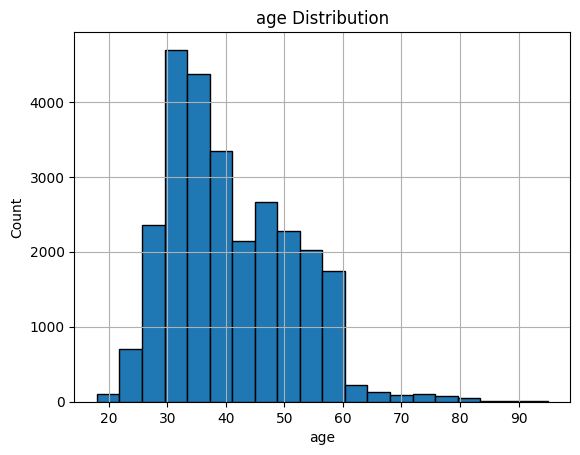

ageとyの相関


np.float64(0.02089190450074562)

In [ ]:
train_data["age"].plot.hist(bins=20, edgecolor="black")
plt.title("age Distribution")
plt.xlabel("age")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("ageとyの相関")
train_data["age"].corr(train_data["y"])

ageは中年層が多く、相関もかなり弱い。

In [ ]:
over60 = train_data[train_data["age"] >= 60]
print(over60["age"].corr(over60["y"]))
under25 = train_data[train_data["age"] <= 25]
print(under25["age"].corr(under25["y"]))

0.14601180703867728
-0.11856875024400361


60歳以上、25歳以下に限定しても相関が弱い。

In [ ]:
job_y = pd.DataFrame({
  "job_cat": train_data["job"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("jobとyの相関")
job_y["job_cat"].corr(job_y["y"])

jobとyの相関


np.float64(0.037901113012530484)

jobも相関が無さそうなので使わない。

In [ ]:
marital_y = pd.DataFrame({
  "marital_cat": train_data["marital"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("maritalとyの相関")
marital_y["marital_cat"].corr(marital_y["y"])

maritalとyの相関


np.float64(0.04547893572515797)

maritalも相関が弱い。

In [ ]:
education_y = pd.DataFrame({
  "education_cat": train_data["education"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("educationとyの相関")
education_y["education_cat"].corr(education_y["y"])

educationとyの相関


np.float64(0.06282198105114649)

educationも相関が無さそう。

In [ ]:
default_y = pd.DataFrame({
  "default_cat": train_data["default"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("defaultとyの相関")
print(default_y["default_cat"].corr(default_y["y"]))
train_data[train_data["default"] == "yes"]["y"].value_counts()

defaultとyの相関
-0.01700546152665874


,count
y,
0,447
1,37


defaultがyesのところだけ抜き出しても相関は無さそう。

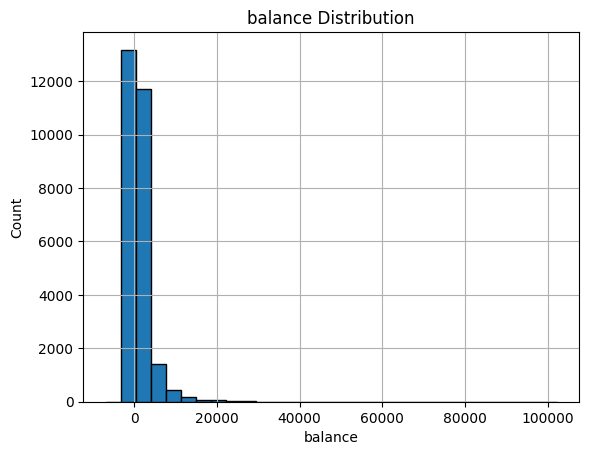

balanceとyの相関


np.float64(0.045826325532616764)

In [ ]:
train_data["balance"].plot.hist(bins=30, edgecolor="black")
plt.title("balance Distribution")
plt.xlabel("balance")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("balanceとyの相関")
train_data["balance"].corr(train_data["y"])

もう少し調べてみる。

In [ ]:
balance_over14000 = train_data.loc[train_data["balance"] >= 14000, ["balance", "y"]]
print("balance(14000以上)とyの相関")
balance_over14000["balance"].corr(balance_over14000["y"])

balance(14000以上)とyの相関


np.float64(0.0008510562664631158)

In [ ]:
balance_under0 = train_data.loc[train_data["balance"] < 0, ["balance", "y"]]
print("balance(0未満)とyの相関")
balance_under0["balance"].corr(balance_under0["y"])

balance(0未満)とyの相関


np.float64(-0.0021653785256377832)

balanceも使えなさそう。

In [ ]:
housing_y = pd.DataFrame({
  "housing_cat": train_data["housing"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("housingとyの相関")
housing_y["housing_cat"].corr(housing_y["y"])

housingとyの相関


np.float64(-0.14030653393906997)

In [ ]:
loan_y = pd.DataFrame({
  "loan_cat": train_data["loan"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("housingとyの相関")
loan_y["loan_cat"].corr(loan_y["y"])

housingとyの相関


np.float64(-0.06562953884522128)

housingとloanは似た傾向にありそうだが、積極的に使えるほどの相関ではない。特にloan。

In [ ]:
contact_y = pd.DataFrame({
  "contact_cat": train_data["contact"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("loanとyの相関")
contact_y["contact_cat"].corr(contact_y["y"])

loanとyの相関


np.float64(-0.15001606161162098)

contactは意外と相関があったが、unknownが多い為、使いたくはない

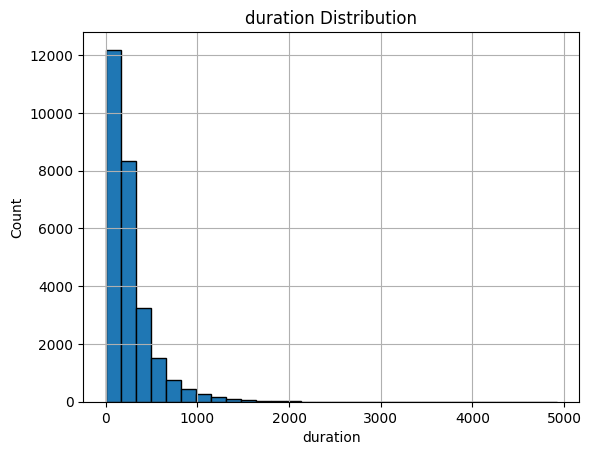

durationとyの相関


np.float64(0.40139042940686437)

In [ ]:
train_data["duration"].plot.hist(bins=30, edgecolor="black")
plt.title("duration Distribution")
plt.xlabel("duration")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("durationとyの相関")
train_data["duration"].corr(train_data["y"])

In [ ]:
train_data["duration"].value_counts().sort_index()

,count
duration,
0,2
2,2
3,2
4,7
5,21
...,...
3102,1
3284,1
3322,1


durationとyの相関はそこそこ強く出た。最低値が0なのが気になるがcountが2なので外れ値として処理しなくても良さそう。逆に高すぎる数字を出しているものは、一定値にまで抑えて使用したい。

mean 260.711295
std  260.091727

なので、一旦はおよそ3σにあたる1000に設定する。

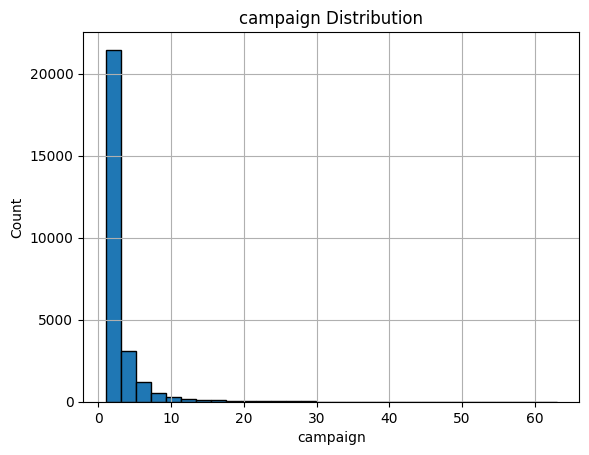

campaignとyの相関


np.float64(-0.0761178357782267)

In [ ]:
train_data["campaign"].plot.hist(bins=30, edgecolor="black")
plt.title("campaign Distribution")
plt.xlabel("campaign")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("campaignとyの相関")
train_data["campaign"].corr(train_data["y"])

In [ ]:
campaign_data = train_data["campaign"].value_counts().sort_index()
pd.concat([campaign_data.head(10), campaign_data.tail()])

,count
campaign,
1,10555
2,7599
3,3295
4,2070
5,1021
6,762
7,445
8,319
9,195


campaignは意外と相関が無い。

In [ ]:
train_data["pdays"].value_counts().sort_index()

,count
pdays,
-1,22146
1,12
2,23
3,1
4,2
...,...
808,1
826,1
831,1


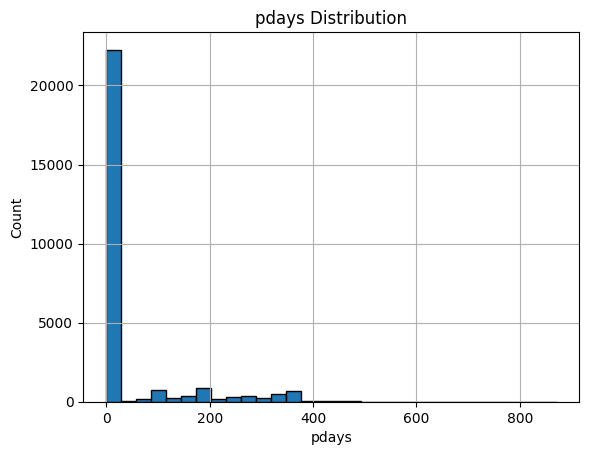

pdaysとyの相関


np.float64(0.10092989063506098)

In [ ]:
train_data["pdays"].plot.hist(bins=30, edgecolor="black")
plt.title("pdays Distribution")
plt.xlabel("pdays")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("pdaysとyの相関")
train_data["pdays"].corr(train_data["y"])

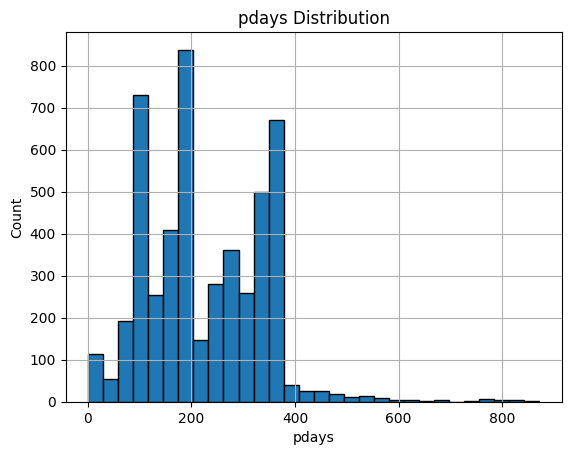

-1を除いたpdaysとyの相関


np.float64(-0.15697783648160932)

In [ ]:
exclude_minus1 = train_data[train_data["pdays"] != -1]

exclude_minus1["pdays"].plot.hist(bins=30, edgecolor="black")
plt.title("pdays Distribution")
plt.xlabel("pdays")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("-1を除いたpdaysとyの相関")
exclude_minus1["pdays"].corr(exclude_minus1["y"])

-1の値が多すぎたためにそれを削除したデータでも相関を取ってみたが、pdaysもあまり強い相関があるとは言えなかった。

In [ ]:
previous_data = train_data["previous"].value_counts().sort_index()
pd.concat([previous_data.head(10), previous_data.tail()])

,count
previous,
0,22146
1,1684
2,1273
3,689
4,445
5,264
6,166
7,117
8,82


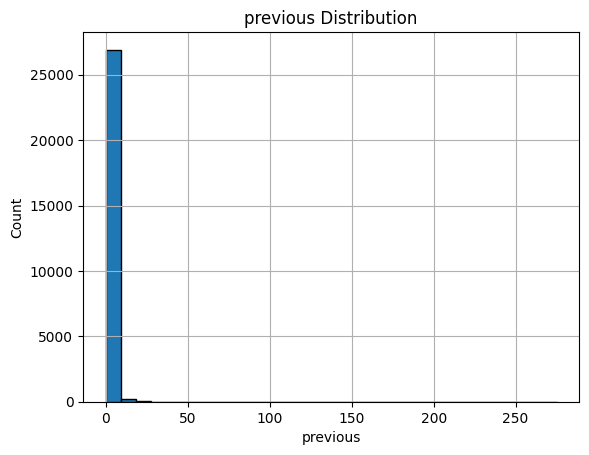

previousとyの相関


np.float64(0.08382532249261533)

In [ ]:
train_data["previous"].plot.hist(bins=30, edgecolor="black")
plt.title("previous Distribution")
plt.xlabel("previous")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("previousとyの相関")
train_data["previous"].corr(train_data["y"])

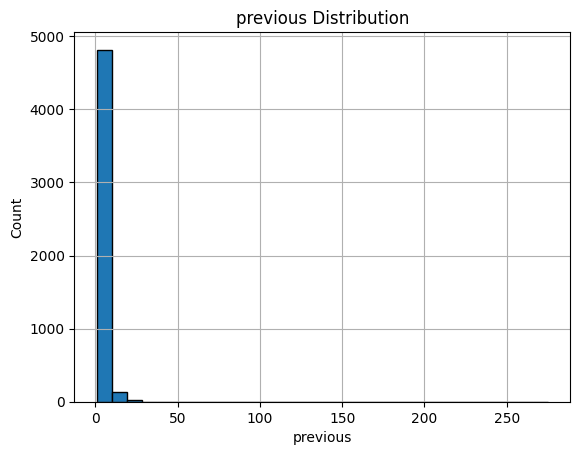

0を除いたpreviousとyの相関


np.float64(0.006680953935543461)

In [ ]:
exclude_zero = train_data[train_data["previous"] != 0]

exclude_zero["previous"].plot.hist(bins=30, edgecolor="black")
plt.title("previous Distribution")
plt.xlabel("previous")
plt.ylabel("Count")
plt.grid(True)
plt.show()
print("0を除いたpreviousとyの相関")
exclude_zero["previous"].corr(exclude_zero["y"])

previousとyの相関も無い。

In [ ]:
poutcome_y = pd.DataFrame({
  "poutcome_cat": train_data["poutcome"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("poutcomeとyの相関")
poutcome_y["poutcome_cat"].corr(poutcome_y["y"])

poutcomeとyの相関


np.float64(-0.07903697734107222)

In [ ]:
exclude_unknown = train_data[train_data["poutcome"] != "unknown"]

exclude_unknown_y = pd.DataFrame({
  "poutcome_cat": exclude_unknown["poutcome"].astype("category").cat.codes,
  "y": train_data["y"]
})
print("unknownを削除したpoutcomeとyの相関")
exclude_unknown_y["poutcome_cat"].corr(exclude_unknown_y["y"])

unknownを削除したpoutcomeとyの相関


np.float64(0.4073276449031324)

unkonnのデータを削除したputcomeはそこそこの相関を示した。ほかに使えそうな説明変数が少ないので、これをどうにか形にしたい

In [ ]:
unknown_data = train_data[train_data["poutcome"] == "unknown"]
pdays_previous_counts = unknown_data.groupby(["pdays", "previous"]).size().sort_index()
pdays_previous_counts

,,0
pdays,previous,
-1,0,22146
98,1,1
168,5,1
188,2,1
528,7,1


In [ ]:
known_data = train_data[train_data["poutcome"] != "unknown"]
pdays_previous_counts = known_data.groupby(["pdays", "previous"]).size().sort_index()
pdays_previous_counts

pdays  previous
1      1           5
       2           1
       3           1
       5           1
       6           2
                  ..
808    12          1
826    1           1
831    1           1
838    3           1
871    2           1
Length: 1880, dtype: int64

poutcomeの値がunknownだった場合、pdaysとpreviousの値もほぼ一定となる。

poutcomeカラムをone-hotベクトル化してみる。

In [ ]:
poutcome_y = train_data[["poutcome", "y"]]
poutcome_y = pd.get_dummies(poutcome_y, columns=["poutcome"])
poutcome_y.corr()

,y,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
y,1.000000,0.016025,0.023954,0.303472,-0.164607
poutcome_failure,0.016025,1.000000,-0.072850,-0.064415,-0.739478
poutcome_other,0.023954,-0.072850,1.000000,-0.038184,-0.438350
poutcome_success,0.303472,-0.064415,-0.038184,1.000000,-0.387595
poutcome_unknown,-0.164607,-0.739478,-0.438350,-0.387595,1.000000


poutcomeがsuccessの値の時だけ相関が取れたので、これを採用する。

# 相関係数だけ見ると使えそうな変数が少なすぎる

現状で使えそうなものが
*   duration
*   poutcome(successの場合のみ)

だけという由々しき事態なので、もう少し探してみる。

In [ ]:
job_y = train_data[["job", "y"]]
job_y = pd.get_dummies(job_y, columns=["job"])
job_y.corr()

,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
y,1.000000,0.008689,-0.071971,-0.017122,-0.014899,0.030974,0.077087,0.004024,-0.027410,0.081543,-0.014642,0.025624,-0.004015
job_admin.,0.008689,1.000000,-0.188558,-0.066887,-0.061019,-0.183106,-0.083276,-0.068052,-0.114278,-0.051863,-0.159549,-0.062038,-0.029111
job_blue-collar,-0.071971,-0.188558,1.000000,-0.098292,-0.089670,-0.269079,-0.122376,-0.100004,-0.167935,-0.076214,-0.234463,-0.091166,-0.042780
job_entrepreneur,-0.017122,-0.066887,-0.098292,1.000000,-0.031808,-0.095450,-0.043410,-0.035474,-0.059571,-0.027035,-0.083170,-0.032339,-0.015175
job_housemaid,-0.014899,-0.061019,-0.089670,-0.031808,1.000000,-0.087077,-0.039602,-0.032362,-0.054345,-0.024664,-0.075874,-0.029502,-0.013844
job_management,0.030974,-0.183106,-0.269079,-0.095450,-0.087077,1.000000,-0.118837,-0.097112,-0.163079,-0.074010,-0.227683,-0.088530,-0.041543
job_retired,0.077087,-0.083276,-0.122376,-0.043410,-0.039602,-0.118837,1.000000,-0.044166,-0.074167,-0.033660,-0.103549,-0.040263,-0.018894
job_self-employed,0.004024,-0.068052,-0.100004,-0.035474,-0.032362,-0.097112,-0.044166,1.000000,-0.060609,-0.027506,-0.084619,-0.032902,-0.015440
job_services,-0.027410,-0.114278,-0.167935,-0.059571,-0.054345,-0.163079,-0.074167,-0.060609,1.000000,-0.046190,-0.142099,-0.055252,-0.025927
job_student,0.081543,-0.051863,-0.076214,-0.027035,-0.024664,-0.074010,-0.033660,-0.027506,-0.046190,1.000000,-0.064489,-0.025075,-0.011767


In [ ]:
marital_y = train_data[["marital", "y"]]
marital_y = pd.get_dummies(marital_y, columns=["marital"])
marital_y.corr()

,y,marital_divorced,marital_married,marital_single
y,1.000000,0.002381,-0.059377,0.062806
marital_divorced,0.002381,1.000000,-0.440830,-0.223498
marital_married,-0.059377,-0.440830,1.000000,-0.776361
marital_single,0.062806,-0.223498,-0.776361,1.000000


In [ ]:
education_y = train_data[["education", "y"]]
education_y = pd.get_dummies(education_y, columns=["education"])
education_y.corr()

,y,education_primary,education_secondary,education_tertiary,education_unknown
y,1.000000,-0.042550,-0.028497,0.059895,0.011429
education_primary,-0.042550,1.000000,-0.435062,-0.273840,-0.088887
education_secondary,-0.028497,-0.435062,1.000000,-0.659649,-0.214118
education_tertiary,0.059895,-0.273840,-0.659649,1.000000,-0.134772
education_unknown,0.011429,-0.088887,-0.214118,-0.134772,1.000000


In [ ]:
contact_y = train_data[["contact", "y"]]
contact_y = pd.get_dummies(contact_y, columns=["contact"])
contact_y.corr()

,y,contact_cellular,contact_telephone,contact_unknown
y,1.000000,0.137388,0.015491,-0.152880
contact_cellular,0.137388,1.000000,-0.349417,-0.866732
contact_telephone,0.015491,-0.349417,1.000000,-0.164483
contact_unknown,-0.152880,-0.866732,-0.164483,1.000000


見つからない！

仕方がないので一旦はdurationとpoutcomeだけでやってみる。

# 実装1(ロジスティック回帰)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def prepare_data1(df):

  # 使わないカラムを削除する
  prepared_df = df.drop(["age", "job", "marital", "education", "default",
                         "balance", "housing", "loan", "contact",
                         "day", "month", "campaign", "pdays", "previous"], axis=1)

  # poutcomeカラムからsuccessの値だけを取り出したpoutcome_successカラムを作成する
  prepared_df["poutcome_success"] = (prepared_df["poutcome"] == "success").astype(int)
  prepared_df = prepared_df.drop(["poutcome"], axis=1) # poutcomeカラムは削除する

  # durationが1000以上の値のデータを1000に統一する
  prepared_df.loc[prepared_df["duration"] >= 1000, "duration"] = 1000

  return prepared_df

In [ ]:
# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# データ成形
train_data = prepare_data1(train_data)
y = train_data["y"]
X = train_data.drop("y", axis = 1)

# 学習用データを学習用とテスト用に分けて実装
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test) #閾値0.5

# 正解率（Accuracy）
print("Accuracy:", accuracy_score(y_test, y_pred))
# ROC-AUC（確率を出したときの評価指標）
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
# 詳細なレポート
print(classification_report(y_test, y_pred))

Accuracy: 0.8971618134906008
ROC-AUC: 0.8506139299901225
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4791
           1       0.62      0.31      0.42       635

    accuracy                           0.90      5426
   macro avg       0.77      0.64      0.68      5426
weighted avg       0.88      0.90      0.88      5426



1のrecallが低すぎる為、一度閾値を変更して実行。

In [ ]:
y_pred = (y_probs >= 0.2).astype(int) #閾値カスタム

# 正解率（Accuracy）
print("Accuracy:", accuracy_score(y_test, y_pred))
# ROC-AUC（確率を出したときの評価指標）
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
# 詳細なレポート
print(classification_report(y_test, y_pred))

Accuracy: 0.8785477331367489
ROC-AUC: 0.8506139299901225
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      4791
           1       0.48      0.58      0.53       635

    accuracy                           0.88      5426
   macro avg       0.71      0.75      0.73      5426
weighted avg       0.89      0.88      0.88      5426



1のrecall自体は良化。ほかが微妙に悪化。

現在欲しいのは確率y_probsの値なので別の方向性で考えてみる。

In [ ]:
# キャリブレーション

base_model = LogisticRegression()
calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='sigmoid')
# calibrated_model = CalibratedClassifierCV(base_model, cv=5, method='isotonic')

calibrated_model.fit(X_train, y_train)

y_probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

y_probs = calibrated_model.predict_proba(X_test)[:, 1]     # 確率
y_pred = calibrated_model.predict(X_test)                  # 閾値0.5で分類

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print(classification_report(y_test, y_pred))

brier_score = brier_score_loss(y_test, y_probs_calibrated)
print("Brier Score:", brier_score)

Accuracy: 0.8971618134906008
ROC-AUC: 0.8506523879255231
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4791
           1       0.62      0.31      0.42       635

    accuracy                           0.90      5426
   macro avg       0.77      0.64      0.68      5426
weighted avg       0.88      0.90      0.88      5426

Brier Score: 0.07795360249371991


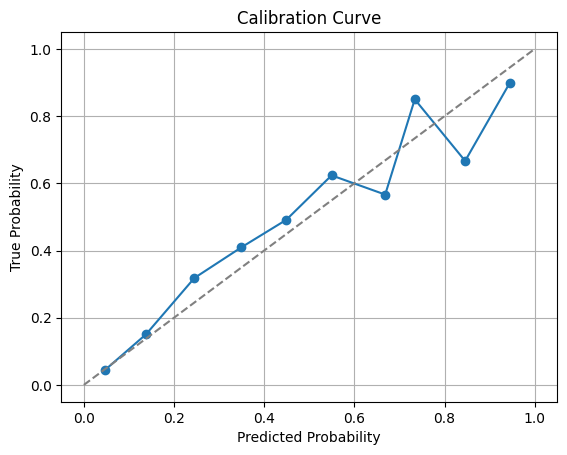

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_probs_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # 完全な理想線
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.grid()
plt.show()

視覚化した分には悪くなさそうだが、別に数値が良くなったわけではない。

# 実装2(LightGBM)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

Mounted at /content/drive


In [ ]:
def prepare_data1(df):

  # 使わないカラムを削除する
  prepared_df = df.drop(["age", "job", "marital", "education", "default",
                         "balance", "housing", "loan", "contact",
                         "day", "month", "campaign", "pdays", "previous"], axis=1)

  #poutcomeカラムからsuccessの値だけを取り出したpoutcome_successカラムを作成する
  prepared_df["poutcome_success"] = (prepared_df["poutcome"] == "success").astype(int)
  prepared_df = prepared_df.drop(["poutcome"], axis=1) # poutcomeカラムは削除する

  # durationが1000以上の値のデータを1000に統一する
  prepared_df.loc[prepared_df["duration"] >= 1000, "duration"] = 1000

  return prepared_df

In [ ]:
# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# データ成形
train_data = prepare_data1(train_data)
y = train_data["y"]
X = train_data.drop("y", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# LightGBM 用データセット
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# パラメータ設定
params = {
  "objective": "binary",
  "metric": "auc",
  "boosting_type": "gbdt",
  "learning_rate": 0.05,
  "num_leaves": 31,
  "feature_fraction": 0.8,
  "bagging_fraction": 0.8,
  "bagging_freq": 5,
  "seed": 42,
  "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1])
}

# モデル学習
model = lgb.train(
  params,
  train_data,
  valid_sets=[train_data, test_data],
  num_boost_round=1000,
  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

# 確率予測
y_probs = model.predict(X_test)

# 閾値0.5で分類
y_pred = (y_probs >= 0.5).astype(int)

# 評価
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 2539, number of negative: 19163
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 257
[LightGBM] [Info] Number of data points in the train set: 21702, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116994 -> initscore=-2.021211
[LightGBM] [Info] Start training from score -2.021211
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.857639	valid_1's auc: 0.843458
Early stopping, best iteration is:
[40]	training's auc: 0.855542	valid_1's auc: 0.845778
Accuracy: 0.8333947659417619
ROC-AUC: 0.8457780911387331
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      4791
           1       0.38      0.67      0.49       635

    accuracy                           0.83      5426
   macro avg       0.67     

# がむしゃらにやってみる

以下、すべての説明変数を一旦採用し、減らしたり変形したりすることで点数の上下を観察して取捨選択する方法で行った。
現在の形になるまでの過程は省く。
モデルはLightGBM

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import lightgbm as lgb

In [6]:
def prepare_data2(df):
  prepared_df = df.copy()

  # pdays = -1 を「未接触フラグ」として別カラム化
  prepared_df["pdays_missing"] = (prepared_df["pdays"] == -1).astype(int)

  # educationをone-hotベクトル化
  prepared_df["education_tertiary"] = (prepared_df["education"] == "tertiary").astype(int)
  prepared_df["education_secondary"] = (prepared_df["education"] == "secondary").astype(int)
  prepared_df["education_primary"] = (prepared_df["education"] == "primary").astype(int)
  # prepared_df["education_unknown"] = (prepared_df["education"] == "unknown").astype(int)
  prepared_df.drop(["education"], axis=1, inplace=True)

  # poutcomeをone-hotベクトル化
  prepared_df["poutcome_success"] = (prepared_df["poutcome"] == "success").astype(int)
  # prepared_df["poutcome_failure"] = (prepared_df["poutcome"] == "failure").astype(int)
  # prepared_df["poutcome_other"] = (prepared_df["poutcome"] == "other").astype(int)
  prepared_df.drop(["poutcome"], axis=1, inplace=True)

  # durationが1000以上の値のデータを1000に統一する
  # prepared_df.loc[prepared_df["duration"] >= 1000, "duration"] = 1000
  # prepared_df.loc[prepared_df["previous"] >= 8, "previous"] = 8
  # prepared_df.loc[prepared_df["balance"] >= 10000, "balance"] = 10000
  # prepared_df.loc[prepared_df["campaign"] >= 12, "campaign"] = 12
  # prepared_df.loc[prepared_df["pdays"] >= 350, "pdays"] = 350

  # 数値変数のログ変換
  for col in ["balance", "campaign", "pdays", "duration", "previous"]:
    prepared_df[col] = prepared_df[col].apply(lambda x: np.log1p(x) if x > 0 else 0)
  # for col in ["balance", "campaign", "pdays"]:
  #   prepared_df[col] = prepared_df[col].apply(lambda x: x if x > 0 else 0)

  # カテゴリ変数をone-hotベクトル化
  # cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month"]
  cat_cols = ["marital", "housing", "loan", "contact", "month"]
  prepared_df = pd.get_dummies(prepared_df, columns=cat_cols, drop_first=True)
  prepared_df.drop(["job", "default"], axis=1, inplace=True)

  return prepared_df

[LightGBM] [Info] Number of positive: 2539, number of negative: 19163
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 980
[LightGBM] [Info] Number of data points in the train set: 21702, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116994 -> initscore=-2.021211
[LightGBM] [Info] Start training from score -2.021211
Training until validation scores don't improve for 100 rounds
[100]	training's auc: 0.953265	valid_1's auc: 0.927903
[200]	training's auc: 0.96732	valid_1's auc: 0.9278
Early stopping, best iteration is:
[106]	training's auc: 0.95433	valid_1's auc: 0.928224
Accuracy: 0.852377441946185
ROC-AUC: 0.9282240158302065
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      4791
           1       0.44      0.88      0.58       635

    accuracy                  

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

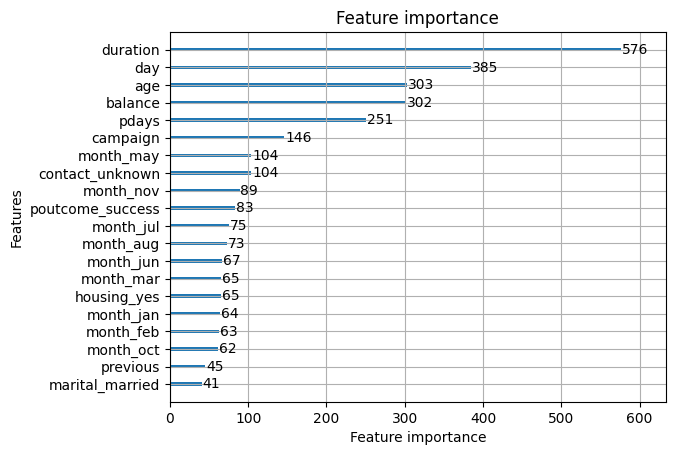

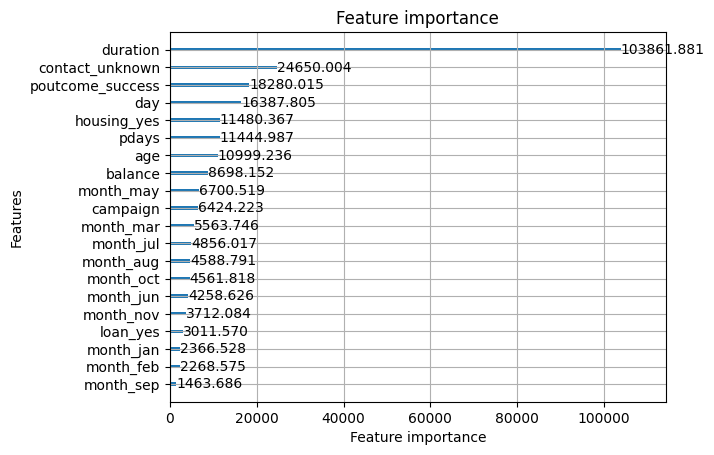

In [7]:
# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# データ成形
train_data = prepare_data2(train_data)
y = train_data["y"]
X = train_data.drop("y", axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# LightGBM 用データセット
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# パラメータ設定
params = {
  "objective": "binary",
  "metric": "auc",
  "boosting_type": "gbdt",
  "learning_rate": 0.05,
  "num_leaves": 31,
  "feature_fraction": 0.8,
  "bagging_fraction": 0.8,
  "bagging_freq": 5,
  "seed": 42,
  "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1])
}

# モデル学習
model = lgb.train(
  params,
  train_data,
  valid_sets=[train_data, test_data],
  num_boost_round=1000,
  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

# 確率予測
y_probs = model.predict(X_test)

# 閾値0.5で分類
y_pred = (y_probs >= 0.5).astype(int)

# 評価
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
print(classification_report(y_test, y_pred))

lgb.plot_importance(model, importance_type="split", max_num_features=20)
lgb.plot_importance(model, importance_type="gain", max_num_features=20)

In [9]:
# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# データ成形
train_data = prepare_data2(train_data)
y = train_data["y"]
X = train_data.drop("y", axis = 1)

# 学習用データを学習用とテスト用に分けて実装
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test) #閾値0.5

# 正解率（Accuracy）
print("Accuracy:", accuracy_score(y_test, y_pred))
# ROC-AUC（確率を出したときの評価指標）
print("ROC-AUC:", roc_auc_score(y_test, y_probs))
# 詳細なレポート
print(classification_report(y_test, y_pred))

Accuracy: 0.8958717287136012
ROC-AUC: 0.8952445283725884
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      4791
           1       0.61      0.32      0.42       635

    accuracy                           0.90      5426
   macro avg       0.76      0.64      0.68      5426
weighted avg       0.88      0.90      0.88      5426



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


やってみて分かったこと

*   相関係数が高いものは役に立つが、相関係数が低いものが役に立たないわけじゃない
*   説明変数が少ない場合はロジスティック回帰、多い場合はLightGBMの方が優秀



# 結果出力

一旦prepared_data2で実装

In [10]:
# 全データ使用

# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# test.csv
test_data = pd.read_csv("test.csv", index_col=0)
test_data.index.name = None

# データ成形
train_data = prepare_data2(train_data)
y_train = train_data["y"]
X_train = train_data.drop("y", axis = 1)
test_data = prepare_data2(test_data)

# LightGBM 用データセット
lgb_train = lgb.Dataset(X_train, label=y_train)

# パラメータ設定
params = {
  "objective": "binary",
  "metric": "auc",
  "boosting_type": "gbdt",
  "learning_rate": 0.05,
  "num_leaves": 31,
  "feature_fraction": 0.8,
  "bagging_fraction": 0.8,
  "bagging_freq": 5,
  "seed": 42,
  "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1])
}

# モデル学習
model = lgb.train(
  params,
  lgb_train,
  num_boost_round=1000,
)

# 確率予測
y_probs = model.predict(test_data)

# 提出用csvファイル作成
submission = pd.DataFrame({
  "index": np.arange(1, len(y_probs)+1),
  "prediction": np.round(y_probs, 3)   # 小数点第3位まで
})

submission.to_csv("bankcustomer_submission1.csv",
                  index=False, header=False)


print("完了")

[LightGBM] [Info] Number of positive: 3174, number of negative: 23954
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 983
[LightGBM] [Info] Number of data points in the train set: 27128, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.117001 -> initscore=-2.021143
[LightGBM] [Info] Start training from score -2.021143
完了


In [12]:
submit_sample = pd.read_csv("bankcustomer_submission1.csv",header=None, index_col=0)
submit_sample.columns = [""]
submit_sample.index.name = None
pd.concat([submit_sample.head(), submit_sample.tail()])

,
1,0.947
2,0.920
3,0.000
4,0.000
5,0.095
18079,0.000
18080,0.090
18081,0.000
18082,0.003
18083,0.003


In [13]:
# refit at best_iteration

# train.csv
train_data = pd.read_csv("train.csv", index_col=0)
train_data.index.name = None

# test.csv
test_data = pd.read_csv("test.csv", index_col=0)
test_data.index.name = None

# データ成形
train_data = prepare_data2(train_data)
y_train = train_data["y"]
X_train = train_data.drop("y", axis=1)
test_data = prepare_data2(test_data)

# LightGBM 用データセット
lgb_train = lgb.Dataset(X_train, label=y_train)

# train/valid 分割
X_tr, X_val, y_tr, y_val = train_test_split(
  X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
lgb_train = lgb.Dataset(X_tr, label=y_tr)
lgb_valid = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# パラメータ設定
params = {
  "objective": "binary",
  "metric": "auc",
  "boosting_type": "gbdt",
  "learning_rate": 0.05,
  "num_leaves": 31,
  "feature_fraction": 0.8,
  "bagging_fraction": 0.8,
  "bagging_freq": 5,
  "seed": 42,
  "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1])
}

# モデル学習（early stopping 有効）
model = lgb.train(
  params,
  lgb_train,
  valid_sets=[lgb_train, lgb_valid],
  valid_names=["train", "valid"],
  num_boost_round=1000,
  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

# 確率予測
y_probs = model.predict(test_data)

# 提出用csvファイル作成
submission = pd.DataFrame({
  "index": np.arange(1, len(y_probs)+1),
  "prediction": np.round(y_probs, 3)   # 小数点第3位まで
})

submission.to_csv(
  "bankcustomer_submission2.csv",
  index=False, header=False
)

print("完了")


[LightGBM] [Info] Number of positive: 2539, number of negative: 19163
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002649 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 980
[LightGBM] [Info] Number of data points in the train set: 21702, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116994 -> initscore=-2.021211
[LightGBM] [Info] Start training from score -2.021211
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.953265	valid's auc: 0.927911
[200]	train's auc: 0.96732	valid's auc: 0.927801
Early stopping, best iteration is:
[106]	train's auc: 0.95433	valid's auc: 0.928231
完了


In [14]:
submit_sample = pd.read_csv("bankcustomer_submission2.csv",header=None, index_col=0)
submit_sample.columns = [""]
submit_sample.index.name = None
pd.concat([submit_sample.head(), submit_sample.tail()])

,
1,0.920
2,0.909
3,0.010
4,0.008
5,0.375
18079,0.009
18080,0.290
18081,0.005
18082,0.019
18083,0.025
